# Portfolio Optimization — Efficient Frontier & Risk Parity

This notebook explores two foundational approaches to portfolio construction:

| Approach | Goal | Inputs needed |
|---|---|---|
| **Mean-Variance (Markowitz)** | Maximize return per unit of risk | Expected returns + covariance |
| **Risk Parity (ERC)** | Equalize risk contribution across assets | Covariance only |

Both approaches answer the question: *how should we allocate capital across assets?*
They just answer it from different angles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import sys
from pathlib import Path

THIS_DIR = Path().resolve()
if str(THIS_DIR) not in sys.path:
    sys.path.insert(0, str(THIS_DIR))

from mean_variance import (
    get_example_data,
    minimum_variance_portfolio,
    maximum_sharpe_portfolio,
    target_return_portfolio,
    compute_efficient_frontier,
    simulate_random_portfolios,
    portfolio_return, portfolio_volatility, portfolio_sharpe,
)
from risk_parity import (
    equal_risk_contribution_portfolio,
    naive_risk_parity,
    risk_contribution_pct,
)

mu, cov, asset_names = get_example_data()
n = len(asset_names)
rf = 0.02

print('Assets:', asset_names)
print('Expected returns:', dict(zip(asset_names, [f'{r:.0%}' for r in mu])))

Assets: ['US Equity', 'Intl Equity', 'Bonds', 'Real Estate', 'Commodities', 'Cash']
Expected returns: {'US Equity': '10%', 'Intl Equity': '9%', 'Bonds': '4%', 'Real Estate': '8%', 'Commodities': '6%', 'Cash': '2%'}


---
## 1. The Feasible Set & Efficient Frontier

Any combination of our assets produces a portfolio with some (return, volatility) pair.
The cloud of all possible portfolios is the **feasible set**.
The **efficient frontier** is the upper-left boundary — portfolios that achieve the highest return for a given level of risk.

No rational investor would hold a portfolio below the frontier, because they could get more return for the same risk.

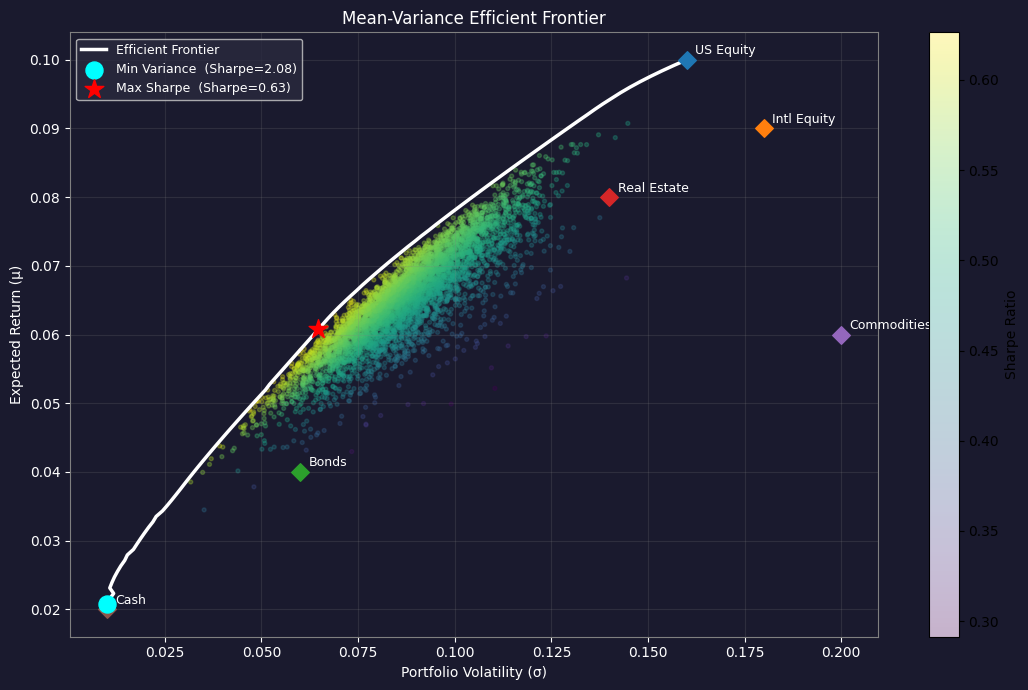

In [2]:
# ---- Simulate random portfolios ----
sim = simulate_random_portfolios(mu, cov, n_portfolios=5000, rf=rf)

# ---- Compute efficient frontier ----
frontier_vols, frontier_rets = compute_efficient_frontier(mu, cov, n_points=100)

# ---- Key portfolios ----
mvp = minimum_variance_portfolio(mu, cov)
msr = maximum_sharpe_portfolio(mu, cov, rf=rf)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(11, 7))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

sc = ax.scatter(sim['vols'], sim['returns'], c=sim['sharpes'],
                cmap='viridis', alpha=0.3, s=8)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

ax.plot(frontier_vols, frontier_rets, color='white', linewidth=2.5,
        label='Efficient Frontier', zorder=5)
ax.scatter(mvp['volatility'], mvp['return'], color='cyan', s=150, zorder=10,
           label=f"Min Variance  (Sharpe={mvp['sharpe']:.2f})")
ax.scatter(msr['volatility'], msr['return'], color='red', s=200,
           marker='*', zorder=10, label=f"Max Sharpe  (Sharpe={msr['sharpe']:.2f})")

asset_vols = np.sqrt(np.diag(cov))
for i, name in enumerate(asset_names):
    ax.scatter(asset_vols[i], mu[i], s=80, zorder=8, marker='D')
    ax.annotate(name, (asset_vols[i], mu[i]),
                textcoords='offset points', xytext=(6, 4), fontsize=9, color='white')

for spine in ax.spines.values():
    spine.set_edgecolor('gray')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
ax.set_xlabel('Portfolio Volatility (σ)')
ax.set_ylabel('Expected Return (μ)')
ax.set_title('Mean-Variance Efficient Frontier')
ax.legend(fontsize=9, facecolor='#2a2a3e', labelcolor='white')
ax.grid(alpha=0.2, color='gray')
plt.tight_layout()
plt.show()

---
## 2. Key Portfolios

Two portfolios on the efficient frontier stand out:

- **Minimum Variance Portfolio (MVP)**: the leftmost point — lowest possible volatility regardless of return
- **Maximum Sharpe Portfolio (Tangency)**: highest return per unit of risk — the optimal risky portfolio when combined with a risk-free asset

In [3]:
print('=== Minimum Variance Portfolio ===')
for name, w in zip(asset_names, mvp['weights']):
    print(f'  {name:<15} {w:.1%}')
print(f'  Return: {mvp["return"]:.2%}  |  Vol: {mvp["volatility"]:.2%}  |  Sharpe: {mvp["sharpe"]:.2f}')

print()
print('=== Maximum Sharpe Portfolio ===')
for name, w in zip(asset_names, msr['weights']):
    print(f'  {name:<15} {w:.1%}')
print(f'  Return: {msr["return"]:.2%}  |  Vol: {msr["volatility"]:.2%}  |  Sharpe: {msr["sharpe"]:.2f}')

=== Minimum Variance Portfolio ===
  US Equity       0.0%
  Intl Equity     0.6%
  Bonds           1.1%
  Real Estate     0.1%
  Commodities     0.0%
  Cash            98.2%
  Return: 2.07%  |  Vol: 1.00%  |  Sharpe: 2.08

=== Maximum Sharpe Portfolio ===
  US Equity       23.4%
  Intl Equity     1.5%
  Bonds           56.6%
  Real Estate     12.0%
  Commodities     6.6%
  Cash            0.0%
  Return: 6.09%  |  Vol: 6.47%  |  Sharpe: 0.63


---
## 3. Portfolio Composition Along the Frontier

As target return increases from MVP to maximum, how do weights shift?
This stacked area chart shows the asset mix at every point on the frontier.

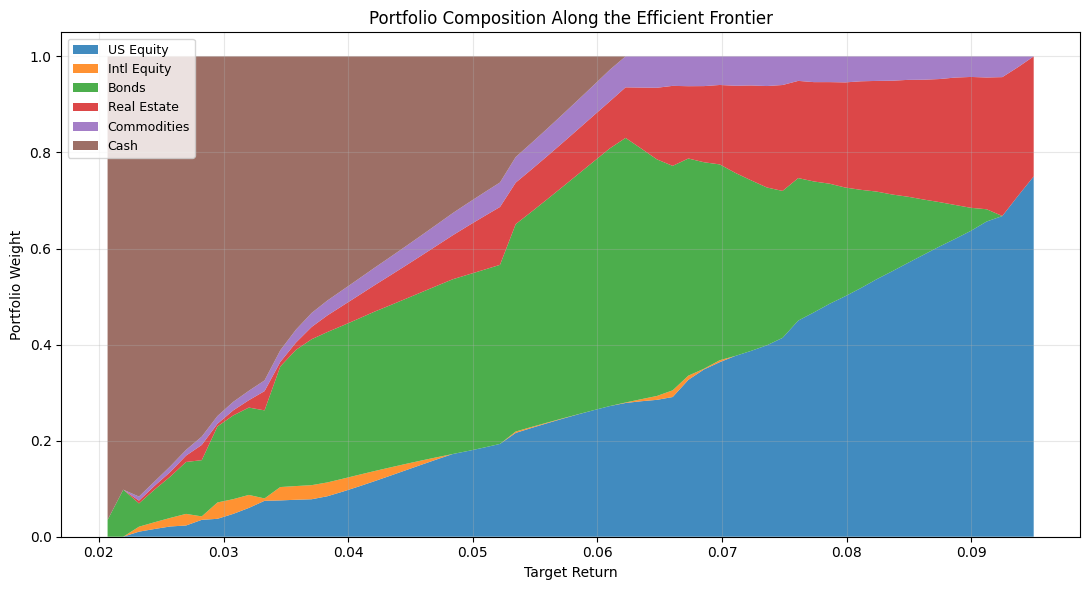

In [4]:
target_returns = np.linspace(mvp['return'], mu.max() * 0.95, 60)
weight_matrix, feasible_rets = [], []

for tr in target_returns:
    p = target_return_portfolio(mu, cov, tr)
    if p is not None:
        weight_matrix.append(p['weights'])
        feasible_rets.append(p['return'])

weight_matrix = np.array(weight_matrix)

fig, ax = plt.subplots(figsize=(11, 6))
ax.stackplot(feasible_rets, weight_matrix.T, labels=asset_names, alpha=0.85)
ax.set_xlabel('Target Return')
ax.set_ylabel('Portfolio Weight')
ax.set_title('Portfolio Composition Along the Efficient Frontier')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Risk Parity — Equal Risk Contribution

Mean-variance optimization is extremely sensitive to return estimates. Small errors in expected returns produce wildly different portfolios. Risk parity sidesteps this by ignoring return estimates entirely.

The **Equal Risk Contribution (ERC)** portfolio allocates weights so that every asset contributes the same fraction of total portfolio risk:

$$RC_i = w_i \cdot \frac{(\Sigma w)_i}{\sqrt{w^\top \Sigma w}} = \frac{1}{n} \quad \forall i$$

This tends to produce more diversified, balanced portfolios that are more robust to estimation error.

In [5]:
w_ew  = np.ones(n) / n
w_nrp = naive_risk_parity(cov)
erc   = equal_risk_contribution_portfolio(cov)
w_erc = erc['weights']

print('=== Equal Risk Contribution Portfolio ===')
print(f'{"Asset":<15} {"Weight":>8} {"Risk Contrib":>14}')
print('-' * 40)
for name, w, rc in zip(asset_names, w_erc, erc['risk_contributions']):
    print(f'{name:<15} {w:>8.1%} {rc:>14.1%}')
print(f'\nPortfolio Vol: {erc["volatility"]:.2%}')
print(f'Converged: {erc["converged"]}')

=== Equal Risk Contribution Portfolio ===
Asset             Weight   Risk Contrib
----------------------------------------
US Equity           3.0%          16.7%
Intl Equity         2.8%          16.7%
Bonds              12.7%          16.7%
Real Estate         3.7%          16.7%
Commodities         3.4%          16.7%
Cash               74.4%          16.7%

Portfolio Vol: 1.91%
Converged: True


### 4a — Weights vs Risk Contributions Across Strategies

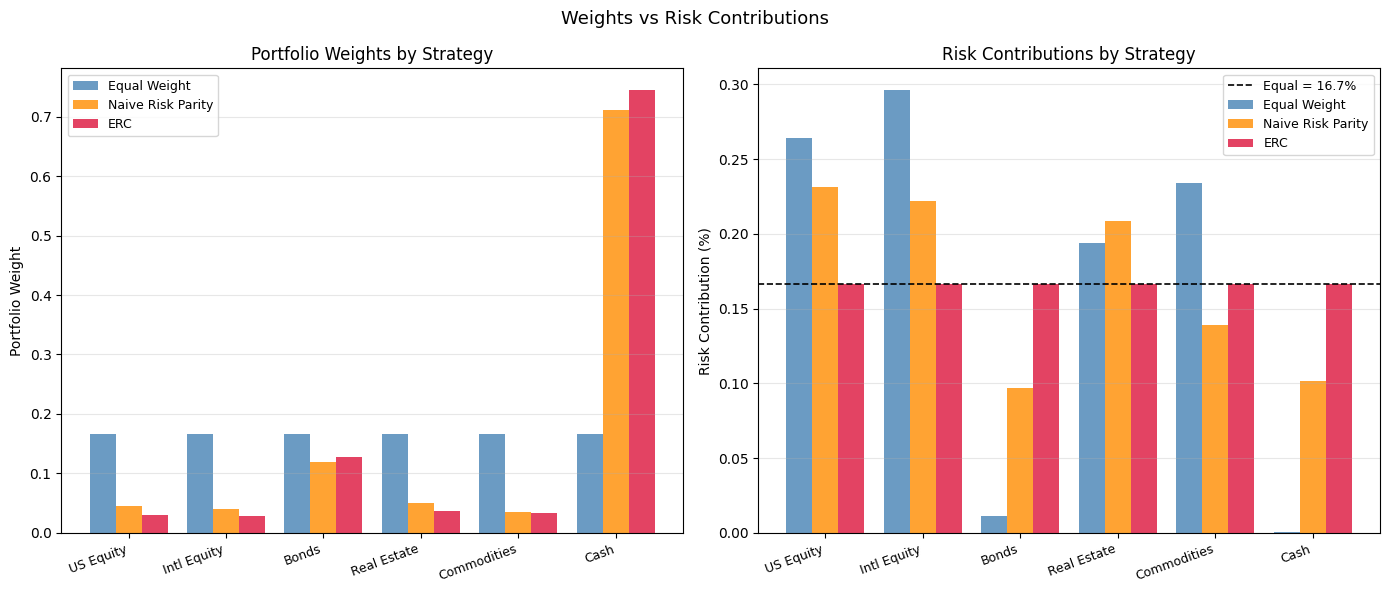

In [6]:
strategies = {'Equal Weight': w_ew, 'Naive Risk Parity': w_nrp, 'ERC': w_erc}
colors = ['steelblue', 'darkorange', 'crimson']
x = np.arange(n)
width = 0.8 / len(strategies)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (label, w) in enumerate(strategies.items()):
    axes[0].bar(x + i * width, w, width, label=label, color=colors[i], alpha=0.8)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(asset_names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Portfolio Weight')
axes[0].set_title('Portfolio Weights by Strategy')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3, axis='y')

for i, (label, w) in enumerate(strategies.items()):
    rc = risk_contribution_pct(w, cov)
    axes[1].bar(x + i * width, rc, width, label=label, color=colors[i], alpha=0.8)

axes[1].axhline(1/n, color='black', linestyle='--', linewidth=1.2,
                label=f'Equal = {1/n:.1%}')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(asset_names, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Risk Contribution (%)')
axes[1].set_title('Risk Contributions by Strategy')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Weights vs Risk Contributions', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Strategy Comparison

Compare all four approaches across return, volatility, Sharpe ratio, and diversification ratio.

The **diversification ratio** is the weighted average of individual asset volatilities divided by portfolio volatility. A higher ratio means the portfolio benefits more from diversification.

Strategy                 Return      Vol   Sharpe  Div Ratio
--------------------------------------------------------------
Equal Weight              6.50%    8.32%     0.54      1.502
Naive Risk Parity         3.32%    2.34%     0.56      1.826
ERC                       3.05%    1.91%     0.55      1.924
Max Sharpe                6.09%    6.47%     0.63      1.607


/var/folders/px/w60tmz3n1dj1j_rdvtv7w3s00000gn/T/ipykernel_23932/1927760250.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
/var/folders/px/w60tmz3n1dj1j_rdvtv7w3s00000gn/T/ipykernel_23932/1927760250.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
/var/folders/px/w60tmz3n1dj1j_rdvtv7w3s00000gn/T/ipykernel_23932/1927760250.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
/var/folders/px/w60tmz3n1dj1j_rdvtv7w3s00000gn/T/ipykernel_23932/1927760250.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. a

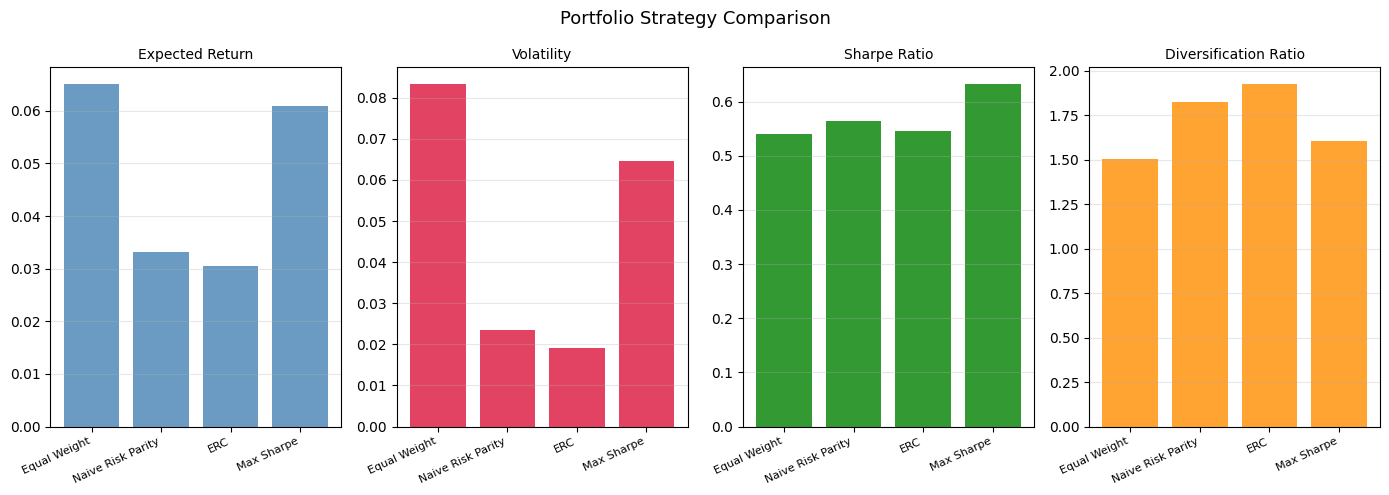

In [7]:
vols_individual = np.sqrt(np.diag(cov))
w_msr = msr['weights']

all_strategies = {
    'Equal Weight':      w_ew,
    'Naive Risk Parity': w_nrp,
    'ERC':               w_erc,
    'Max Sharpe':        w_msr,
}

metrics = {}
for name, w in all_strategies.items():
    pv = np.sqrt(w @ cov @ w)
    pr = w @ mu
    metrics[name] = {
        'return':    pr,
        'vol':       pv,
        'sharpe':    (pr - rf) / pv,
        'div_ratio': (w @ vols_individual) / pv,
    }

print(f'{"Strategy":<22} {"Return":>8} {"Vol":>8} {"Sharpe":>8} {"Div Ratio":>10}')
print('-' * 62)
for name, m in metrics.items():
    print(f'{name:<22} {m["return"]:>8.2%} {m["vol"]:>8.2%} '
          f'{m["sharpe"]:>8.2f} {m["div_ratio"]:>10.3f}')

labels = list(metrics.keys())
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for ax, key, title, color in zip(
    axes,
    ['return', 'vol', 'sharpe', 'div_ratio'],
    ['Expected Return', 'Volatility', 'Sharpe Ratio', 'Diversification Ratio'],
    ['steelblue', 'crimson', 'green', 'darkorange'],
):
    vals = [metrics[l][key] for l in labels]
    ax.bar(labels, vals, color=color, alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Portfolio Strategy Comparison', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Summary

| Strategy | Strengths | Weaknesses |
|---|---|---|
| **Equal Weight** | Simple, no estimation needed | Ignores all risk and return info |
| **Naive Risk Parity** | Low vol assets get more weight | Only looks at individual vol, ignores correlations |
| **ERC** | True risk diversification, no return estimates | Requires covariance matrix; ignores returns |
| **Max Sharpe** | Theoretically optimal if inputs are correct | Very sensitive to return estimates; can be highly concentrated |

**Key insight:** Mean-variance gives the highest Sharpe ratio *if you trust your return estimates*. Risk parity gives the most balanced risk distribution *if you don't*. In practice, most institutional portfolios combine both perspectives.

**Next:** `evaluation/risk_metrics.py` — measuring portfolio risk with VaR, CVaR, Sharpe, max drawdown, and more.